In [12]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from src.objectives.quadratic import QuadraticObjective
from src.schedulers.pipedream_1f1b import PipeDream1F1BScheduler, print_schedule, plot_schedule
from src.methods.pipedream import PipeDreamMethod
from src.methods.gpd import GPDMethod
from src.methods.sgd import SGDMethod
from src.experiments.runner import ExperimentRunner
from src.experiments.compare_methods import compare_methods
from src.plotting.convergence import plot_block_update_comparison
from src.utils.batching import build_training_batch_schedule
from src.state.timeline import num_microbatches_from_timeline

In [14]:
def make_pd_method(
    lr: float,
    timeline,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return PipeDreamMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"PipeDream lr={lr:.3e}",
    )


def make_gpd_method(
    lr: float,
    K_budget: int,
    delta: int,
    training_batch_indices,
    init_stage_weights,
    seed: int,
    name: str | None = None,
):
    return GPDMethod(
        num_iterations=K_budget,
        learning_rate=lr,
        delta=delta,
        seed=seed,
        stage_sampling="uniform",
        batch_sampling="uniform",
        stale_sampling="uniform",

        timeline=timeline,
        
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"GPD lr={lr:.3e}",
    )

def run_trials(objective, method_factory, seeds):
    traces = []
    for seed in seeds:
        method = method_factory(seed)
        trace = method.run(objective)
        traces.append(trace)
    return traces


def aggregate_block_curves(traces, K_budget: int):
    curves = []
    for tr in traces:
        curve = tr.block_update_objective
        if curve is None:
            raise ValueError(f"{tr.method_name} has no block_update_objective.")
        if len(curve) < K_budget:
            raise ValueError(f"Curve too short: len={len(curve)}, required {K_budget}")
        curves.append(curve[:K_budget])
    curves = np.stack(curves, axis=0)
    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "all": curves,
    }

def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
    K_budget: int,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )
        agg = aggregate_block_curves(traces, K_budget=K_budget)
        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"],
            "final_std": agg["final_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])
    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }


def plot_lr_sweep_curves(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
    log_scale: bool = False,
):
    plt.figure(figsize=(9, 5))
    eps = 1e-16

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        y = np.maximum(info["mean_curve"], eps) if log_scale else info["mean_curve"]
        label = f"lr={lr:.3e}"
        if np.isclose(lr, sweep_result["best_lr"]):
            label += "  [best]"
            lw = 2.8
        elif reference_lr is not None and np.isclose(lr, reference_lr):
            label += f"  [{reference_label}]"
            lw = 2.8
        else:
            lw = 1.4

        if log_scale:
            plt.semilogy(y, label=label, linewidth=lw)
        else:
            plt.plot(y, label=label, linewidth=lw)

    plt.xlabel("number of block updates")
    plt.ylabel("full objective")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_lr_sweep_summary(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
):
    lrs = np.array(sorted(sweep_result["results"].keys()))
    means = np.array([sweep_result["results"][lr]["final_mean"] for lr in lrs])
    stds = np.array([sweep_result["results"][lr]["final_std"] for lr in lrs])

    plt.figure(figsize=(7, 4))
    plt.errorbar(lrs, means, yerr=stds, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("learning rate")
    plt.ylabel("final objective at fixed budget")
    plt.title(title)

    if reference_lr is not None:
        plt.axvline(reference_lr, linestyle="--", linewidth=1.5, label=reference_label)
        plt.legend()

    plt.tight_layout()
    plt.show()

In [15]:
# problem setup
num_stages = 10
delta_gpd = num_stages**2 - num_stages // 2  # from the theorem I proved

num_parameters = 10

batch_size = 10
total_batches = 10
num_epochs = 10
seed = 0

num_examples = batch_size * total_batches
num_microbatches = total_batches * num_epochs

objective = QuadraticObjective.synthetic(
    num_examples=num_examples,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    noise_std=0.0,
)

scheduler = PipeDream1F1BScheduler(noam=num_stages)
timeline = scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)

init_stage_weights = objective.initial_stage_weights(mode="zeros", seed=0)

# fixed PipeDream batch order for fairness across PipeDream LR sweeps
num_dataset_batches = len(objective.get_batches())

training_batch_indices = build_training_batch_schedule(
    num_dataset_batches=num_dataset_batches,
    num_microbatches=num_microbatches,
    shuffle_each_epoch=False,
    seed=seed + 1,
)

print("num_dataset_batches =", num_dataset_batches)
print("effective epochs    =", num_microbatches / num_dataset_batches)
print("first training batches =", training_batch_indices[:min(20, len(training_batch_indices))])

# common block-update budget:
# PipeDream naturally defines it
pd_probe = make_pd_method(
    lr=1e-3,
    timeline=timeline,
    training_batch_indices=training_batch_indices,
    init_stage_weights=init_stage_weights,
    name="PipeDream probe",
).run(objective)

K_budget = len(pd_probe.block_update_objective)
print("K_budget =", K_budget)

# useful constants
L = objective.smoothness_constant

print("L =", L)
print("1/L =", 1 / L)

num_dataset_batches = 10
effective epochs    = 10.0
first training batches = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
K_budget = 1000
L = 1.7804846250906423
1/L = 0.5616448386624463


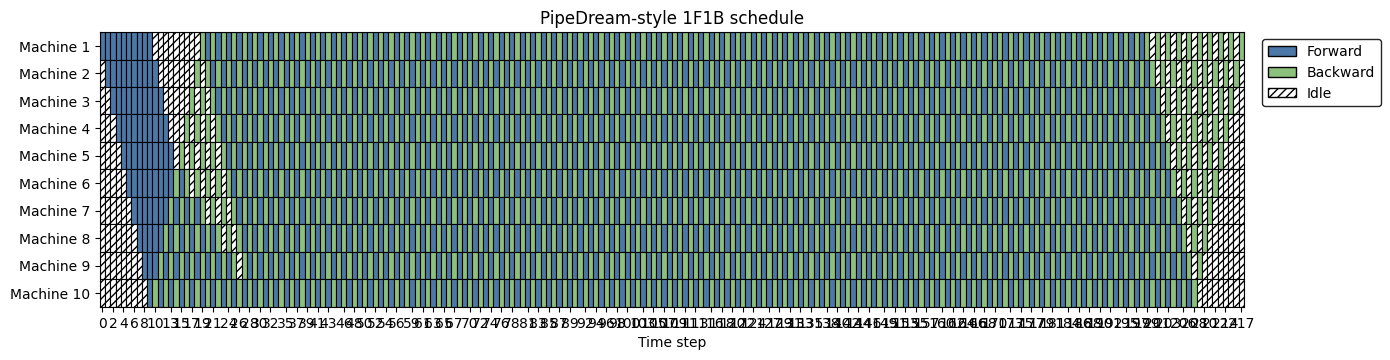

In [16]:
fig, ax = plot_schedule(timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=100)
plt.show()

In [17]:
num_lr_points = 30
gamma_grid = np.linspace(0.01 / L, 0.8 / L, num_lr_points)

print("L =", L)
print("gamma min =", gamma_grid[0])
print("gamma max =", gamma_grid[-1])
print("1/L =", 1.0 / L)

pd_lrs = gamma_grid.copy()

pd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="PipeDream",
    learning_rates=pd_lrs,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr,
        timeline=timeline,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=f"PipeDream lr={lr:.6e}",
    ),
    seeds=[0],
    K_budget=K_budget,
)

print("Best PipeDream lr =", pd_sweep["best_lr"])
print("Best PipeDream lr * L =", pd_sweep["best_lr"] * L)

L = 1.7804846250906423
gamma min = 0.005616448386624463
gamma max = 0.44931587092995706
1/L = 0.5616448386624463
Best PipeDream lr = 0.09741632891283121
Best PipeDream lr * L = 0.17344827586206898


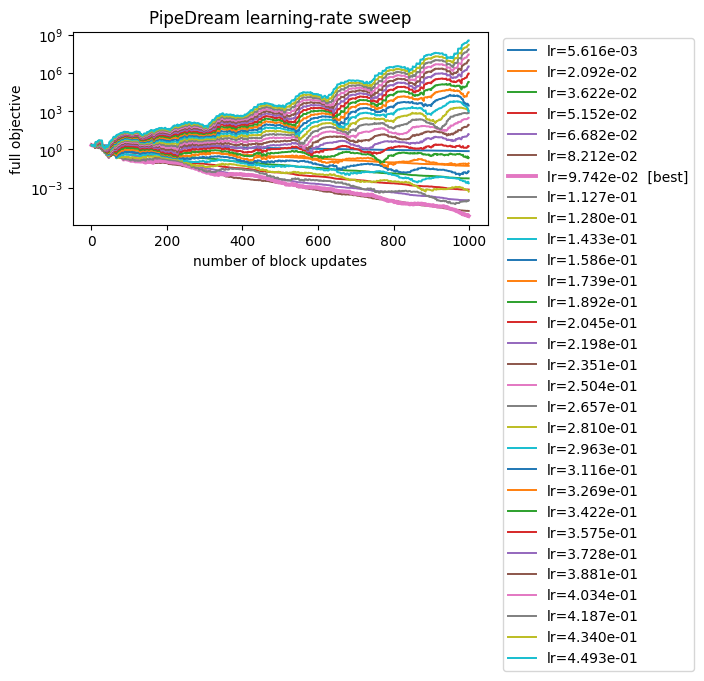

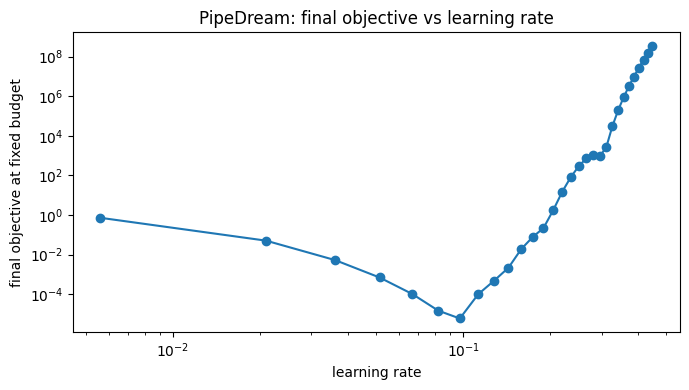

In [18]:
plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    pd_sweep,
    title="PipeDream: final objective vs learning rate",
)

In [19]:
gamma_grid = np.linspace(0.01 / L, 0.8 / L, num_lr_points)

gpd_lrs = gamma_grid.copy()

gpd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="GPD",
    learning_rates=gpd_lrs,
    method_factory_builder=lambda lr, seed: make_gpd_method(
        lr=lr,
        K_budget=K_budget,
        delta=delta_gpd,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"GPD lr={lr:.6e}",
    ),
    seeds=list(range(10)),
    K_budget=K_budget,
)

print("Best GPD lr =", gpd_sweep["best_lr"])
print("Best GPD lr * L =", gpd_sweep["best_lr"] * L)

Best GPD lr = 0.11271630900053234
Best GPD lr * L = 0.2006896551724138


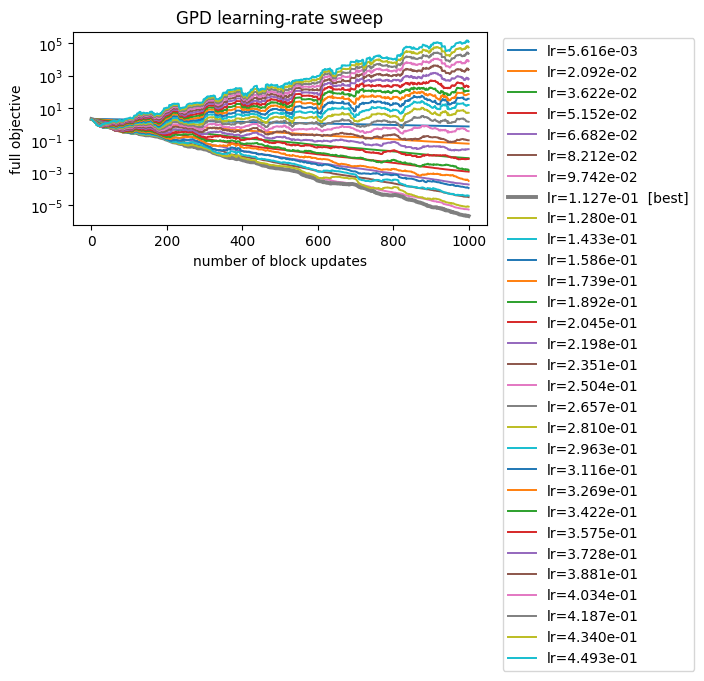

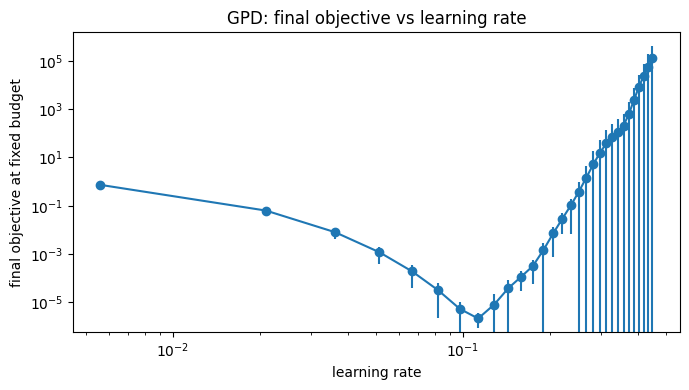

In [20]:
plot_lr_sweep_curves(
    gpd_sweep,
    title="GPD learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    gpd_sweep,
    title="GPD: final objective vs learning rate",
)

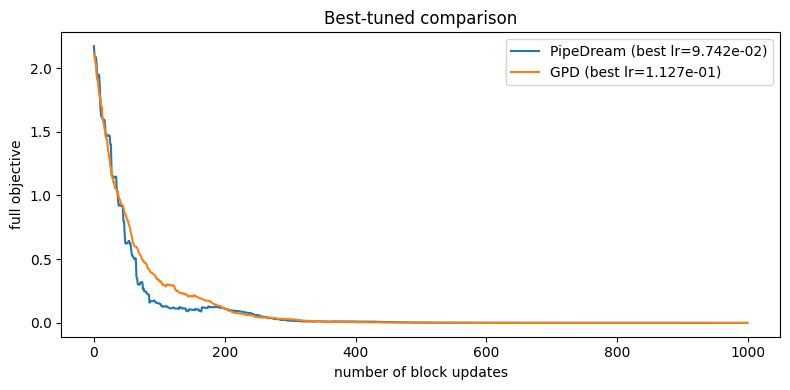

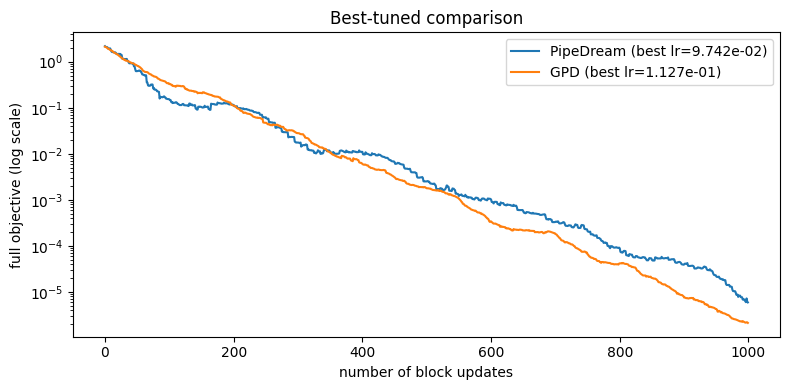

In [21]:
best_pd_curve = pd_sweep["best_curve"]
best_gpd_curve = gpd_sweep["best_curve"]

T = min(len(best_pd_curve), len(best_gpd_curve))

plt.figure(figsize=(8, 4))
plt.plot(best_pd_curve[:T], label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.plot(best_gpd_curve[:T], label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.xlabel("number of block updates")
plt.ylabel("full objective")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
eps = 1e-16
plt.semilogy(np.maximum(best_pd_curve[:T], eps), label=f"PipeDream (best lr={pd_sweep['best_lr']:.3e})")
plt.semilogy(np.maximum(best_gpd_curve[:T], eps), label=f"GPD (best lr={gpd_sweep['best_lr']:.3e})")
plt.xlabel("number of block updates")
plt.ylabel("full objective (log scale)")
plt.title("Best-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

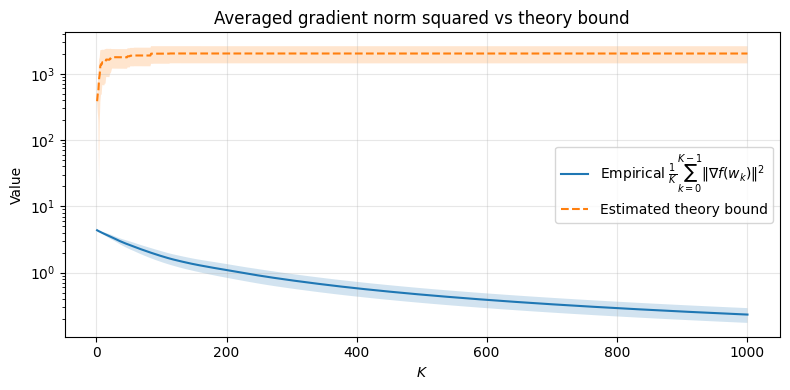

In [22]:
best_trace = gpd_sweep['results'][gpd_sweep['best_lr']]
traces = best_trace['traces']

avg_grad_curves = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in traces],
    axis=0,
)
avg_grad_mean = avg_grad_curves.mean(axis=0)
avg_grad_std = avg_grad_curves.std(axis=0)

bound_curves = np.stack(
    [tr.theory_bound_trace for tr in traces],
    axis=0,
)
bound_mean = bound_curves.mean(axis=0)
bound_std = bound_curves.std(axis=0)

x = np.arange(1, len(avg_grad_mean) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, avg_grad_mean, label=r"Empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$")
ax.fill_between(
    x,
    avg_grad_mean - avg_grad_std,
    avg_grad_mean + avg_grad_std,
    alpha=0.2,
)

ax.plot(x, bound_mean, linestyle="--", label=r"Estimated theory bound")
ax.fill_between(
    x,
    bound_mean - bound_std,
    bound_mean + bound_std,
    alpha=0.2,
)

ax.set_yscale("log")
ax.set_xlabel(r"$K$")
ax.set_ylabel("Value")
ax.set_title("Averaged gradient norm squared vs theory bound")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

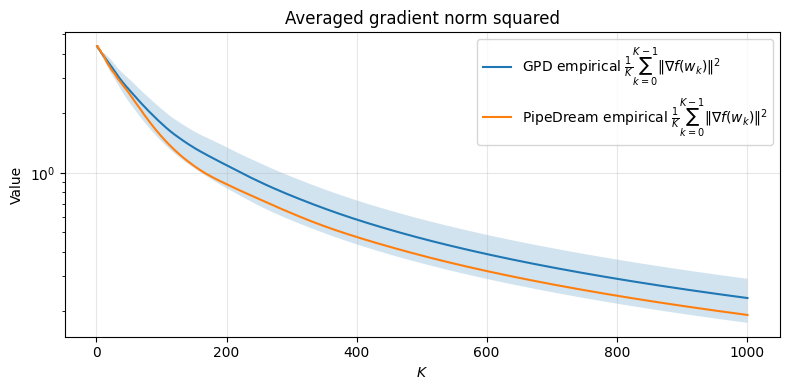

In [33]:
best_trace_gpd = gpd_sweep['results'][gpd_sweep['best_lr']]
gpd_traces = best_trace_gpd['traces']

avg_grad_curves_gpd = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in gpd_traces],
    axis=0,
)
avg_grad_mean_gpd = avg_grad_curves_gpd.mean(axis=0)
avg_grad_std_gpd = avg_grad_curves_gpd.std(axis=0)

bound_curves_gpd = np.stack(
    [tr.theory_bound_trace for tr in gpd_traces],
    axis=0,
)
bound_mean_gpd = bound_curves_gpd.mean(axis=0)
bound_std_gpd = bound_curves_gpd.std(axis=0)


best_trace_pd = pd_sweep['results'][pd_sweep['best_lr']]
pd_traces = best_trace_pd['traces']

avg_grad_curves_pd = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in pd_traces],
    axis=0,
)
avg_grad_mean_pd = avg_grad_curves_pd.mean(axis=0)
avg_grad_std_pd = avg_grad_curves_pd.std(axis=0)


x_gpd = np.arange(1, len(avg_grad_mean_gpd) + 1)
x_pd = np.arange(1, len(avg_grad_mean_pd) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    x_gpd,
    avg_grad_mean_gpd,
    label=r"GPD empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$",
)
ax.fill_between(
    x_gpd,
    avg_grad_mean_gpd - avg_grad_std_gpd,
    avg_grad_mean_gpd + avg_grad_std_gpd,
    alpha=0.2,
)
'''
ax.plot(
    x_gpd,
    bound_mean_gpd,
    linestyle="--",
    label=r"GPD estimated theory bound",
)
ax.fill_between(
    x_gpd,
    bound_mean_gpd - bound_std_gpd,
    bound_mean_gpd + bound_std_gpd,
    alpha=0.2,
)'''

ax.plot(
    x_pd,
    avg_grad_mean_pd,
    label=r"PipeDream empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$",
)
ax.fill_between(
    x_pd,
    avg_grad_mean_pd - avg_grad_std_pd,
    avg_grad_mean_pd + avg_grad_std_pd,
    alpha=0.2,
)

ax.set_yscale("log")
ax.set_xlabel(r"$K$")
ax.set_ylabel("Value")
ax.set_title("Averaged gradient norm squared")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()